In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

print("libraries loaded")

libraries loaded


In [2]:
MY_KEY = "vBFcQd1cXK37hRh5iE8nMwxrTGv7O9J5p4rIS066"

url1 = f"https://api.eia.gov/v2/petroleum/pri/fut/data/?api_key={MY_KEY}&frequency=daily&data[0]=value&facets[series][]=RCLC1&start=2010-01-01&sort[0][column]=period&sort[0][direction]=asc&length=5000"

url4 = f"https://api.eia.gov/v2/petroleum/pri/fut/data/?api_key={MY_KEY}&frequency=daily&data[0]=value&facets[series][]=RCLC4&start=2010-01-01&sort[0][column]=period&sort[0][direction]=asc&length=5000"

r1 = requests.get(url1)
r4 = requests.get(url4)

df1 = pd.DataFrame(r1.json()['response']['data'])[['period','value']].rename(columns={'value':'near'})
df4 = pd.DataFrame(r4.json()['response']['data'])[['period','value']].rename(columns={'value':'far'})

df1['near'] = pd.to_numeric(df1['near'])
df4['far'] = pd.to_numeric(df4['far'])

df = df1.merge(df4, on='period')
df['spread'] = df['far'] - df['near']
df['date'] = pd.to_datetime(df['period'])
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
print(df.head())

(3598, 5)
       period   near    far  spread       date
0  2010-01-04  81.51  83.12    1.61 2010-01-04
1  2010-01-05  81.77  83.52    1.75 2010-01-05
2  2010-01-06  83.18  84.86    1.68 2010-01-06
3  2010-01-07  82.66  84.29    1.63 2010-01-07
4  2010-01-08  82.75  84.47    1.72 2010-01-08


In [3]:
# Calculate log prices and log spread
df['log_near'] = np.log(df['near'])
df['log_far'] = np.log(df['far'])
df['log_spread'] = df['log_far'] - df['log_near']

print(df[['date', 'near', 'far', 'spread', 'log_spread']].head(10))

        date   near    far  spread  log_spread
0 2010-01-04  81.51  83.12    1.61    0.019560
1 2010-01-05  81.77  83.52    1.75    0.021176
2 2010-01-06  83.18  84.86    1.68    0.019996
3 2010-01-07  82.66  84.29    1.63    0.019527
4 2010-01-08  82.75  84.47    1.72    0.020572
5 2010-01-11  82.52  84.14    1.62    0.019441
6 2010-01-12  80.79  82.28    1.49    0.018275
7 2010-01-13  79.65  81.21    1.56    0.019396
8 2010-01-14  79.39  81.11    1.72    0.021434
9 2010-01-15  78.00  79.64    1.64    0.020808


C:\Users\mcmal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


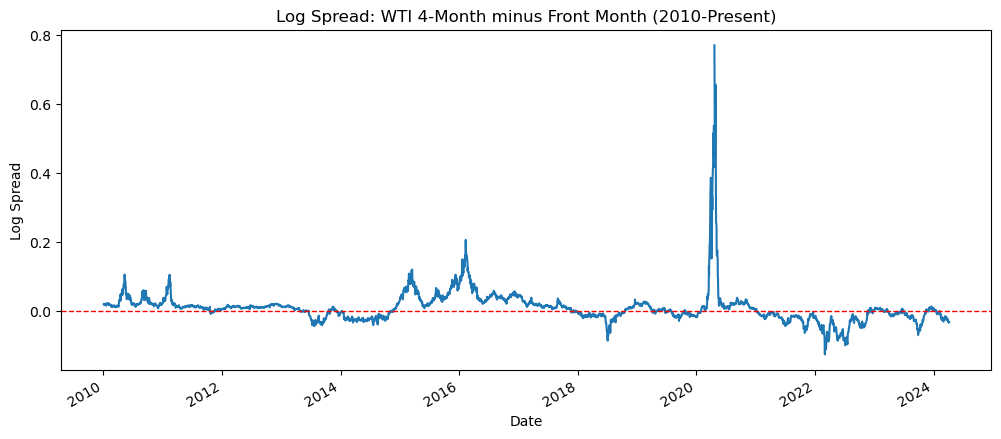

In [4]:
# Plot the log spread over time
df.set_index('date')['log_spread'].plot(
    figsize=(12,5),
    title="Log Spread: WTI 4-Month minus Front Month (2010-Present)"
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.ylabel("Log Spread")
plt.xlabel("Date")
plt.show()

In [5]:
# Calculate daily changes in log spread - this is what the model fits    
df['log_spread_change'] = df['log_spread'].diff()
df = df.dropna().reset_index(drop=True)

print("Mean daily change:", round(df['log_spread_change'].mean(), 6))
print("Std daily change:", round(df['log_spread_change'].std(), 6))
print("Rows remaining:", len(df))

Mean daily change: -7.9e-05
Std daily change: 0.009387
Rows remaining: 3595


In [6]:
# Schwartz 2-factor model
# Factor 1: Long run mean of log spread (chi)
# Factor 2: Short term deviation from mean (xi)

# Step 1 - Estimate the long run mean
chi = df['log_spread'].mean()
print("Long run mean (chi):", round(chi, 6))

# Step 2 - Calculate short term deviation
df['xi'] = df['log_spread'] - chi
print("\nFirst 5 short term deviations:")
print(df[['date', 'log_spread', 'xi']].head())

Long run mean (chi): 0.00951

First 5 short term deviations:
        date  log_spread        xi
0 2010-01-05    0.021176  0.011666
1 2010-01-06    0.019996  0.010486
2 2010-01-07    0.019527  0.010018
3 2010-01-08    0.020572  0.011063
4 2010-01-11    0.019441  0.009932


In [7]:
# Step 2 - Estimate mean reversion speed
# How fast does xi pull back toward zero?
# We measure this by regressing today's xi on yesterday's xi

xi = df['xi'].values
xi_lag = xi[:-1]   # yesterday's xi
xi_today = xi[1:]  # today's xi

# Simple linear regression kappa = 1 - beta, *98.2% of yesterday's xi shows up in today's xi* *
kappa = 1 - np.cov(xi_today, xi_lag)[0,1] / np.var(xi_lag)
print("Mean reversion speed (kappa):", round(kappa, 6))
print("Half life of shocks (days):", round(np.log(2)/kappa, 1))

Mean reversion speed (kappa): 0.01823
Half life of shocks (days): 38.0


In [8]:
sigma_xi = df['xi'].std()
sigma_spread = df['log_spread_change'].std()
 #square root of 252 because of left right step example
print("Volatility of short term factor (sigma_xi):", round(sigma_xi, 6))
print("Volatility of daily spread changes (sigma):", round(sigma_spread, 6))
print("Annualized spread volatility:", round(sigma_spread * np.sqrt(252), 4))

Volatility of short term factor (sigma_xi): 0.047719
Volatility of daily spread changes (sigma): 0.009387
Annualized spread volatility: 0.149


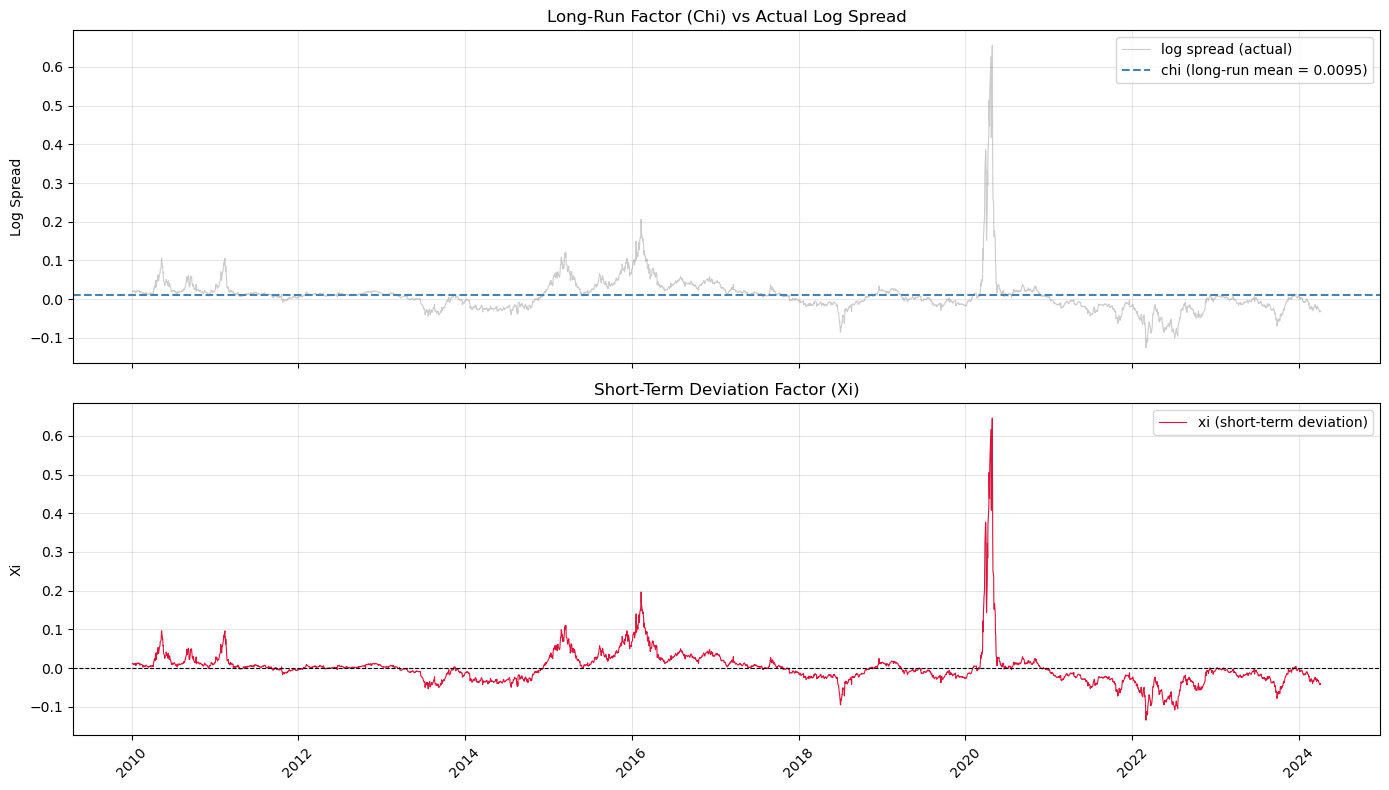

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['date'], df['log_spread'], alpha=0.4, color='gray', linewidth=0.8, label='log spread (actual)')
axes[0].axhline(y=chi, color='steelblue', linewidth=1.5, linestyle='--', label=f'chi (long-run mean = {chi:.4f})')
axes[0].set_ylabel('Log Spread')
axes[0].set_title('Long-Run Factor (Chi) vs Actual Log Spread')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['date'], df['xi'], color='crimson', linewidth=0.8, label='xi (short-term deviation)')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Xi')
axes[1].set_title('Short-Term Deviation Factor (Xi)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('schwartz_factors.png', dpi=150, bbox_inches='tight')
plt.show()

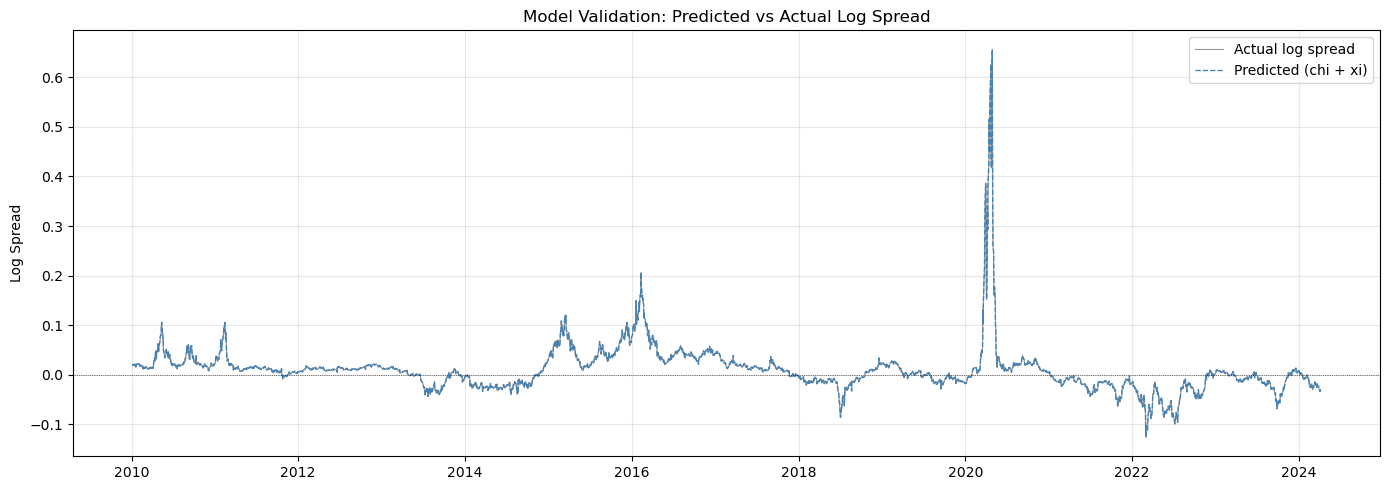

Correlation between actual and predicted: 1.0000


In [10]:
df['predicted_log_spread'] = chi + df['xi']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['log_spread'], label='Actual log spread', color='gray', linewidth=0.8, alpha=0.8)
ax.plot(df['date'], df['predicted_log_spread'], label='Predicted (chi + xi)', color='steelblue', linewidth=1.0, linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle=':')
ax.set_title('Model Validation: Predicted vs Actual Log Spread')
ax.set_ylabel('Log Spread')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_validation.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df['log_spread'].corr(df['predicted_log_spread'])
print(f"Correlation between actual and predicted: {corr:.4f}")

In [18]:

# Install if needed
import subprocess
subprocess.run(['pip', 'install', 'hmmlearn', '--quiet'])

from hmmlearn.hmm import GaussianHMM
import numpy as np

# Prepare features for HMM
# We use xi and log_spread_change as our two signals
features = df[['xi', 'log_spread_change']].values

# Fit 2-state HMM
model = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000, random_state=42)
model.fit(features)

# Extract regime for every day
df['regime'] = model.predict(features)

print("Regime counts:")
print(df['regime'].value_counts())
print("\nRegime means (xi):")
for i in range(2):
    mask = df['regime'] == i
    print(f"  Regime {i}: mean xi = {df.loc[mask, 'xi'].mean():.4f}, count = {mask.sum()}")

Regime counts:
regime
1    3119
0     476
Name: count, dtype: int64

Regime means (xi):
  Regime 0: mean xi = 0.0381, count = 476
  Regime 1: mean xi = -0.0058, count = 3119


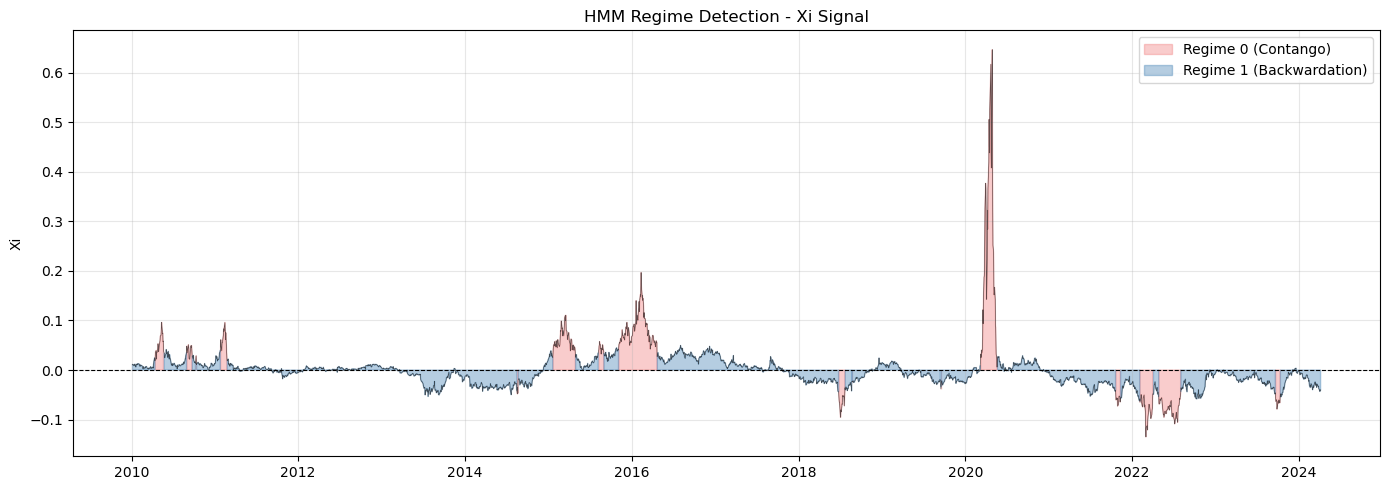

In [19]:
pythonfig, ax = plt.subplots(figsize=(14, 5))

colors = {0: 'lightcoral', 1: 'steelblue'}
labels = {0: 'Regime 0 (Contango)', 1: 'Regime 1 (Backwardation)'}

for regime in [0, 1]:
    mask = df['regime'] == regime
    ax.fill_between(df['date'], df['xi'], where=mask,
                    alpha=0.4, color=colors[regime], label=labels[regime])

ax.plot(df['date'], df['xi'], color='black', linewidth=0.5, alpha=0.6)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('HMM Regime Detection - Xi Signal')
ax.set_ylabel('Xi')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regimes.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Phase 4 - Backtest
# Strategy:
# Regime 0 (contango) -> sell far, buy near -> we profit when spread narrows
# Regime 1 (backwardation) -> buy far, sell near -> we profit when spread widens back
# P&L proxy = daily change in spread, sign depends on regime

# Define position based on regime
# Contango (0): we are short the spread, so we make money when spread decreases
# Backwardation (1): we are long the spread, so we make money when spread increases

df['position'] = df['regime'].map({0: -1, 1: 1})

# Daily P&L = position * next day's spread change
# We shift because today's regime signal drives tomorrow's trade
df['daily_pnl'] = df['position'].shift(1) * df['log_spread_change']

# Drop the first row which will be NaN
df = df.dropna(subset=['daily_pnl']).reset_index(drop=True)

# Cumulative P&L
df['cum_pnl'] = df['daily_pnl'].cumsum()

print("Total P&L:", round(df['daily_pnl'].sum(), 4))
print("Number of trading days:", len(df))
print("Win rate:", round((df['daily_pnl'] > 0).mean(), 4))

Total P&L: 0.2238
Number of trading days: 3590
Win rate: 0.5067


Sharpe Ratio: 0.1054
Max Drawdown: -0.5461


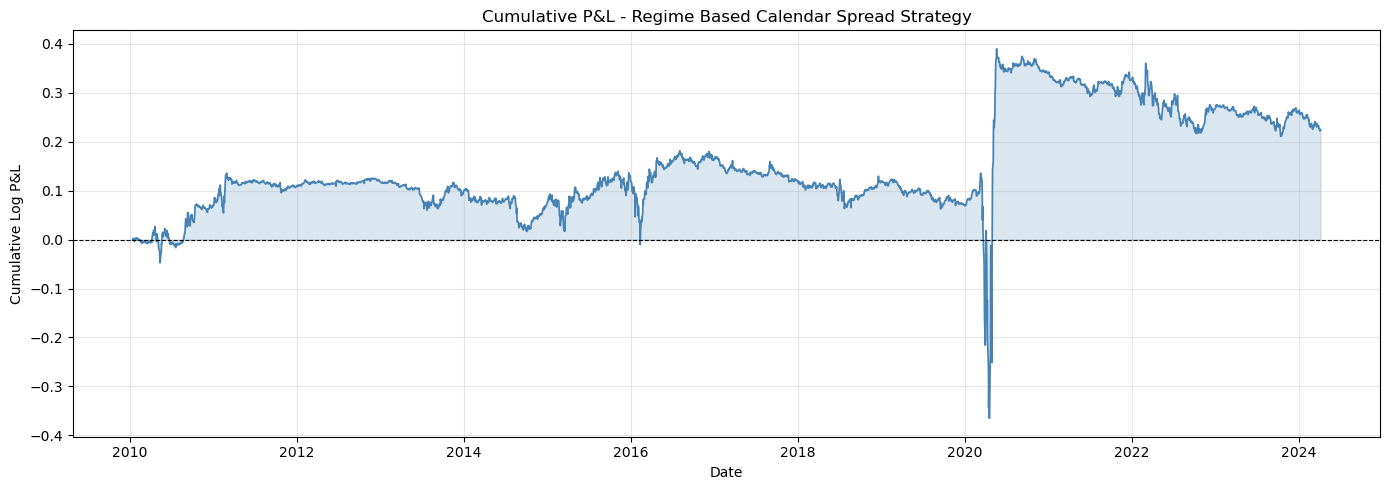

In [28]:
# Sharpe ratio (annualized)
sharpe = (df['daily_pnl'].mean() / df['daily_pnl'].std()) * np.sqrt(252)
print(f"Sharpe Ratio: {round(sharpe, 4)}")

# Max drawdown
rolling_max = df['cum_pnl'].cummax()
drawdown = df['cum_pnl'] - rolling_max
max_drawdown = drawdown.min()
print(f"Max Drawdown: {round(max_drawdown, 4)}")

# Plot cumulative P&L
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['cum_pnl'], color='steelblue', linewidth=1.2)
ax.fill_between(df['date'], df['cum_pnl'], alpha=0.2, color='steelblue')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative P&L - Regime Based Calendar Spread Strategy')
ax.set_ylabel('Cumulative Log P&L')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pnl_curve.png', dpi=150, bbox_inches='tight')
plt.show()